# 第2周：凸优化与KKT条件

## 从NP-Hard到多项式时间：凸性的魔力

### 内容
1. 凸集与凸函数
2. 凸性判定（一阶/二阶条件）
3. 凸优化问题（LP, QP, SOCP, SDP）
4. Lagrangian与对偶函数
5. KKT条件
6. 对偶的经济学解释（影子价格）
7. SVM对偶问题实验
8. GPU vs CPU 凸优化对比
9. MDP的线性规划形式

---

✅ 中文字体配置完成！


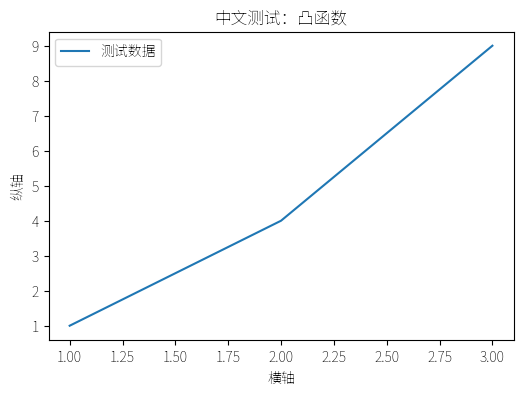

In [6]:
# ============ 中文字体配置（Colab 完整版）============
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import os
import urllib.request

# 0. 先清理旧设置
plt.rcdefaults()

font_name = "NotoSansSC.ttf"

# 1. 下载字体
urls = [
    "https://github.com/google/fonts/raw/main/ofl/notosanssc/NotoSansSC%5Bwght%5D.ttf",
    "https://github.com/googlefonts/noto-cjk/raw/main/Sans/Variable/TTF/NotoSansSC-VF.ttf",
]

if not os.path.exists(font_name) or os.path.getsize(font_name) < 100000:
    for i, url in enumerate(urls):
        try:
            print(f"尝试源 {i+1}...")
            urllib.request.urlretrieve(url, font_name)
            if os.path.getsize(font_name) > 100000:
                print(f"下载成功！{os.path.getsize(font_name)/1024/1024:.2f} MB")
                break
        except Exception as e:
            print(f"源 {i+1} 失败: {e}")

# 2. 注册字体
font_path = os.path.abspath(font_name)
fm.fontManager.addfont(font_path)

# 3. 设置全局（用正确的名字 "Noto Sans SC"）
plt.rcParams['font.sans-serif'] = ['Noto Sans SC']
plt.rcParams['axes.unicode_minus'] = False

print("✅ 中文字体配置完成！")

# 4. 测试
plt.figure(figsize=(6, 4))
plt.plot([1, 2, 3], [1, 4, 9])
plt.title('中文测试：凸函数')
plt.xlabel('横轴')
plt.ylabel('纵轴')
plt.legend(['测试数据'])
plt.show()

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import time
from typing import Tuple, List, Optional

# 检查可选依赖
try:
    import cvxpy as cp
    HAS_CVXPY = True
    print("✓ CVXPY 可用")
except ImportError:
    HAS_CVXPY = False
    print("✗ CVXPY 未安装，部分实验无法运行")
    print("  安装方法: pip install cvxpy")

try:
    import torch
    HAS_TORCH = True
    HAS_CUDA = torch.cuda.is_available()
    print(f"✓ PyTorch 可用 (CUDA: {'可用' if HAS_CUDA else '不可用'})")
except ImportError:
    HAS_TORCH = False
    HAS_CUDA = False
    print("✗ PyTorch 未安装")

plt.rcParams['font.size'] = 12
plt.rcParams['figure.figsize'] = (10, 6)

✓ CVXPY 可用
✓ PyTorch 可用 (CUDA: 可用)


---
## Part 1: 凸集与凸函数

### 1.1 凸集的定义

集合 $C$ 是**凸集**，当且仅当：对任意 $x, y \in C$ 和 $\theta \in [0,1]$，有 $\theta x + (1-\theta)y \in C$

**直觉**：集合内任意两点的连线段都完全在集合内

### 1.2 凸函数的定义

函数 $f$ 是**凸函数**，当且仅当：
$$f(\theta x + (1-\theta)y) \leq \theta f(x) + (1-\theta)f(y)$$

**直觉**：函数图像上任意两点连线在函数图像的**上方**

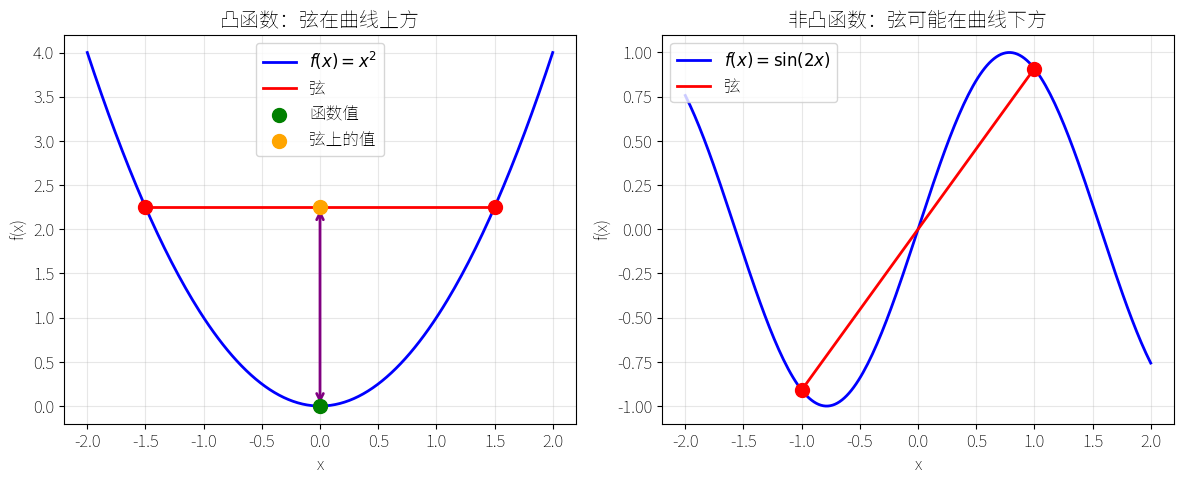

In [8]:
# 可视化凸函数 vs 非凸函数
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

x = np.linspace(-2, 2, 200)

# 凸函数: f(x) = x^2
ax = axes[0]
y_convex = x**2
ax.plot(x, y_convex, 'b-', linewidth=2, label='$f(x) = x^2$')

# 画弦
x1, x2 = -1.5, 1.5
y1, y2 = x1**2, x2**2
ax.plot([x1, x2], [y1, y2], 'r-', linewidth=2, label='弦')
ax.scatter([x1, x2], [y1, y2], color='red', s=100, zorder=5)

# 中点
xm = 0
ax.scatter([xm], [xm**2], color='green', s=100, zorder=5, label='函数值')
ax.scatter([xm], [(y1+y2)/2], color='orange', s=100, zorder=5, label='弦上的值')
ax.annotate('', xy=(xm, (y1+y2)/2), xytext=(xm, xm**2),
            arrowprops=dict(arrowstyle='<->', color='purple', lw=2))

ax.set_xlabel('x')
ax.set_ylabel('f(x)')
ax.set_title('凸函数：弦在曲线上方')
ax.legend()
ax.grid(True, alpha=0.3)

# 非凸函数: f(x) = sin(x)
ax = axes[1]
y_nonconvex = np.sin(2*x)
ax.plot(x, y_nonconvex, 'b-', linewidth=2, label='$f(x) = \\sin(2x)$')

# 画弦
x1, x2 = -1, 1
y1, y2 = np.sin(2*x1), np.sin(2*x2)
ax.plot([x1, x2], [y1, y2], 'r-', linewidth=2, label='弦')
ax.scatter([x1, x2], [y1, y2], color='red', s=100, zorder=5)

ax.set_xlabel('x')
ax.set_ylabel('f(x)')
ax.set_title('非凸函数：弦可能在曲线下方')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## Part 2: 凸性判定

### 一阶条件
$f$ 是凸函数 $\Leftrightarrow$ $f(y) \geq f(x) + \nabla f(x)^T(y-x)$

**几何意义**：函数图像始终在其切平面的上方

### 二阶条件
$f$ 是凸函数 $\Leftrightarrow$ $\nabla^2 f(x) \succeq 0$（Hessian半正定）

**直觉**：二阶导数处处非负 → 函数「向上弯曲」

In [9]:
def is_positive_semidefinite(H: np.ndarray, tol: float = 1e-10) -> bool:
    """判断矩阵是否半正定"""
    eigenvalues = np.linalg.eigvalsh(H)
    return np.all(eigenvalues >= -tol)

def is_positive_definite(H: np.ndarray, tol: float = 1e-10) -> bool:
    """判断矩阵是否正定（强凸条件）"""
    eigenvalues = np.linalg.eigvalsh(H)
    return np.all(eigenvalues > tol)

# 示例：二次函数的凸性
print("二次函数 f(x) = x^T P x 的凸性判定")
print("=" * 50)

# 正定矩阵 -> 强凸
P1 = np.array([[2, 0], [0, 3]])
eig1 = np.linalg.eigvalsh(P1)
print(f"\nP1 = [[2,0],[0,3]]")
print(f"特征值: {eig1}")
print(f"正定: {is_positive_definite(P1)} -> 强凸函数")

# 半正定矩阵 -> 凸
P2 = np.array([[1, 1], [1, 1]])
eig2 = np.linalg.eigvalsh(P2)
print(f"\nP2 = [[1,1],[1,1]]")
print(f"特征值: {eig2}")
print(f"半正定: {is_positive_semidefinite(P2)} -> 凸函数（但不是强凸）")

# 不定矩阵 -> 非凸
P3 = np.array([[1, 2], [2, 1]])
eig3 = np.linalg.eigvalsh(P3)
print(f"\nP3 = [[1,2],[2,1]]")
print(f"特征值: {eig3}")
print(f"半正定: {is_positive_semidefinite(P3)} -> 非凸函数")

二次函数 f(x) = x^T P x 的凸性判定

P1 = [[2,0],[0,3]]
特征值: [2. 3.]
正定: True -> 强凸函数

P2 = [[1,1],[1,1]]
特征值: [0. 2.]
半正定: True -> 凸函数（但不是强凸）

P3 = [[1,2],[2,1]]
特征值: [-1.  3.]
半正定: False -> 非凸函数


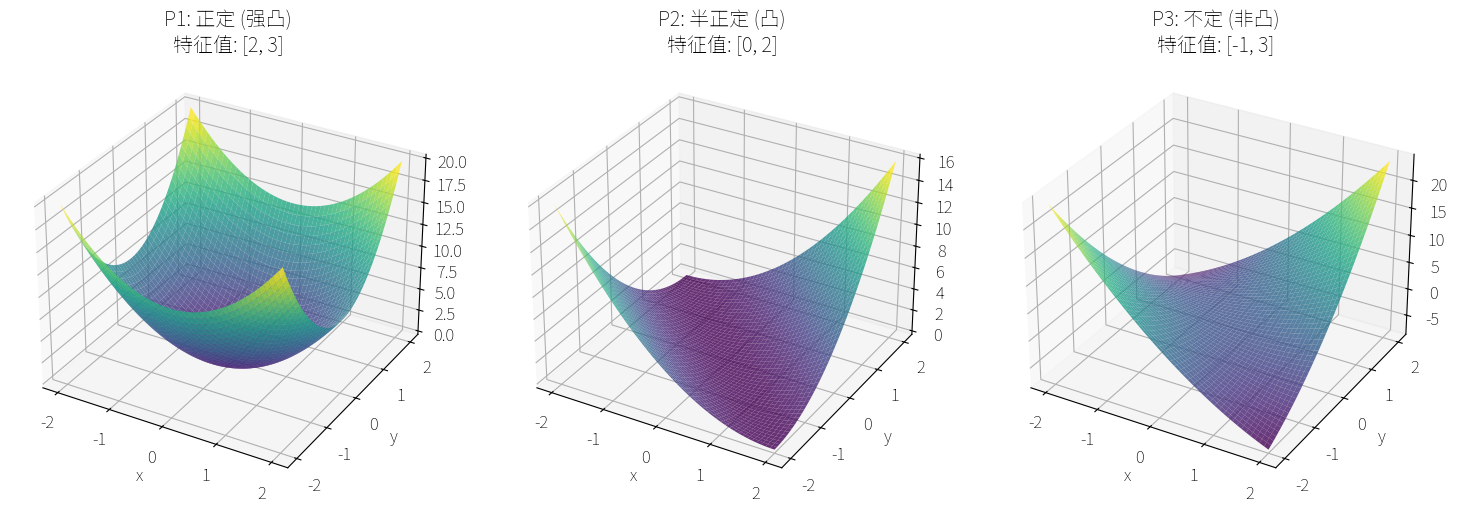

In [10]:
# 可视化二次函数的凸性
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(15, 5))

x = np.linspace(-2, 2, 50)
y = np.linspace(-2, 2, 50)
X, Y = np.meshgrid(x, y)

# P1: 正定 (凸)
ax1 = fig.add_subplot(131, projection='3d')
Z1 = 2*X**2 + 3*Y**2
ax1.plot_surface(X, Y, Z1, cmap='viridis', alpha=0.8)
ax1.set_title('P1: 正定 (强凸)\n特征值: [2, 3]')
ax1.set_xlabel('x')
ax1.set_ylabel('y')

# P2: 半正定 (凸但不强凸)
ax2 = fig.add_subplot(132, projection='3d')
Z2 = X**2 + 2*X*Y + Y**2  # (x+y)^2
ax2.plot_surface(X, Y, Z2, cmap='viridis', alpha=0.8)
ax2.set_title('P2: 半正定 (凸)\n特征值: [0, 2]')
ax2.set_xlabel('x')
ax2.set_ylabel('y')

# P3: 不定 (非凸)
ax3 = fig.add_subplot(133, projection='3d')
Z3 = X**2 + 4*X*Y + Y**2
ax3.plot_surface(X, Y, Z3, cmap='viridis', alpha=0.8)
ax3.set_title('P3: 不定 (非凸)\n特征值: [-1, 3]')
ax3.set_xlabel('x')
ax3.set_ylabel('y')

plt.tight_layout()
plt.show()

---
## Part 3: KKT条件

对于凸优化问题，**KKT条件**是最优性的充要条件：

1. **原始可行性**：$g_i(x^*) \leq 0$，$h_j(x^*) = 0$
2. **对偶可行性**：$\lambda_i^* \geq 0$
3. **互补松弛**：$\lambda_i^* g_i(x^*) = 0$
4. **稳定性**：$\nabla f(x^*) + \sum_i \lambda_i^* \nabla g_i(x^*) + \sum_j \nu_j^* \nabla h_j(x^*) = 0$

In [11]:
# 简单例子：手算KKT条件
print("例子: min x^2  s.t. x >= 1")
print("=" * 50)
print("\n转换为标准形式: min x^2  s.t. 1-x <= 0")
print("\nLagrangian: L(x,λ) = x² + λ(1-x)")
print("\nKKT条件:")
print("  1. 原始可行: x >= 1")
print("  2. 对偶可行: λ >= 0")
print("  3. 互补松弛: λ(1-x) = 0")
print("  4. 稳定性: ∂L/∂x = 2x - λ = 0  =>  λ = 2x")
print("\n求解:")
print("  由稳定性: λ = 2x")
print("  由对偶可行: λ >= 0  =>  x >= 0")
print("  由互补松弛: λ(1-x) = 0")
print("    若 λ = 0，则 x = 0（违反原始可行 x >= 1）")
print("    若 1-x = 0，则 x = 1")
print("  代入稳定性: λ = 2(1) = 2")
print("\n最优解: x* = 1, λ* = 2")
print("最优值: f(x*) = 1")

例子: min x^2  s.t. x >= 1

转换为标准形式: min x^2  s.t. 1-x <= 0

Lagrangian: L(x,λ) = x² + λ(1-x)

KKT条件:
  1. 原始可行: x >= 1
  2. 对偶可行: λ >= 0
  3. 互补松弛: λ(1-x) = 0
  4. 稳定性: ∂L/∂x = 2x - λ = 0  =>  λ = 2x

求解:
  由稳定性: λ = 2x
  由对偶可行: λ >= 0  =>  x >= 0
  由互补松弛: λ(1-x) = 0
    若 λ = 0，则 x = 0（违反原始可行 x >= 1）
    若 1-x = 0，则 x = 1
  代入稳定性: λ = 2(1) = 2

最优解: x* = 1, λ* = 2
最优值: f(x*) = 1


In [12]:
# 使用CVXPY验证
if HAS_CVXPY:
    x = cp.Variable()
    prob = cp.Problem(cp.Minimize(x**2), [x >= 1])
    prob.solve()

    print("\nCVXPY验证:")
    print(f"  x* = {x.value:.4f}")
    print(f"  λ* = {prob.constraints[0].dual_value:.4f}")
    print(f"  最优值 = {prob.value:.4f}")
else:
    print("需要安装 cvxpy 来验证")


CVXPY验证:
  x* = 1.0000
  λ* = 2.0000
  最优值 = 1.0000


---
## Part 4: 影子价格（对偶的经济学解释）

**影子价格定理**：对偶变量 $\lambda_i^*$ 等于「放松约束一个单位，目标函数能改善多少」

$$\lambda_i^* = -\frac{\partial p^*}{\partial \epsilon_i}\bigg|_{\epsilon=0}$$

**互补松弛的经济学意义**：
- 资源有剩余 ($g_i(x^*) < 0$) → 价格为零 ($\lambda_i^* = 0$)
- 资源有价值 ($\lambda_i^* > 0$) → 资源用尽 ($g_i(x^*) = 0$)

In [13]:
if HAS_CVXPY:
    print("生产问题：最小化成本")
    print("=" * 50)
    print("min  2x₁ + 3x₂        (成本)")
    print("s.t. x₁ + x₂ >= 10    (产量需求)")
    print("     x₁ <= 8          (机器A产能)")
    print("     x₂ <= 6          (机器B产能)")
    print("     x₁, x₂ >= 0")

    x1 = cp.Variable()
    x2 = cp.Variable()

    objective = cp.Minimize(2*x1 + 3*x2)
    constraints = [
        x1 + x2 >= 10,   # 产量需求
        x1 <= 8,         # 机器A产能
        x2 <= 6,         # 机器B产能
        x1 >= 0,
        x2 >= 0
    ]

    prob = cp.Problem(objective, constraints)
    prob.solve()

    print(f"\n最优解:")
    print(f"  x₁* = {x1.value:.2f}")
    print(f"  x₂* = {x2.value:.2f}")
    print(f"  最优成本 = {prob.value:.2f}")

    print(f"\n影子价格（对偶变量）:")
    print(f"  产量约束 λ₁ = {abs(constraints[0].dual_value):.2f}")
    print(f"  机器A约束 λ₂ = {constraints[1].dual_value:.2f}")
    print(f"  机器B约束 λ₃ = {constraints[2].dual_value:.2f}")

    print(f"\n经济学解释:")
    print(f"  - 产量需求的影子价格 = {abs(constraints[0].dual_value):.2f}")
    print(f"    产量需求每减少1单位，成本减少约 {abs(constraints[0].dual_value):.2f} 元")
    print(f"  - 机器A产能影子价格 = {constraints[1].dual_value:.2f}")
    print(f"    当前 x₁ = {x1.value:.2f} < 8，产能有剩余，无价值")
    print(f"  - 机器B产能影子价格 = {constraints[2].dual_value:.2f}")
    print(f"    当前 x₂ = {x2.value:.2f} = 6，产能用尽")
else:
    print("需要安装 cvxpy")

生产问题：最小化成本
min  2x₁ + 3x₂        (成本)
s.t. x₁ + x₂ >= 10    (产量需求)
     x₁ <= 8          (机器A产能)
     x₂ <= 6          (机器B产能)
     x₁, x₂ >= 0

最优解:
  x₁* = 8.00
  x₂* = 2.00
  最优成本 = 22.00

影子价格（对偶变量）:
  产量约束 λ₁ = 3.00
  机器A约束 λ₂ = 1.00
  机器B约束 λ₃ = 0.00

经济学解释:
  - 产量需求的影子价格 = 3.00
    产量需求每减少1单位，成本减少约 3.00 元
  - 机器A产能影子价格 = 1.00
    当前 x₁ = 8.00 < 8，产能有剩余，无价值
  - 机器B产能影子价格 = 0.00
    当前 x₂ = 2.00 = 6，产能用尽


In [14]:
# 验证影子价格
if HAS_CVXPY:
    print("验证：放松机器B产能约束")
    print("=" * 50)

    original_cost = prob.value
    lambda3 = constraints[2].dual_value

    # 放松约束: x2 <= 7
    constraints_relaxed = [
        x1 + x2 >= 10,
        x1 <= 8,
        x2 <= 7,  # 放松1单位
        x1 >= 0,
        x2 >= 0
    ]
    prob_relaxed = cp.Problem(objective, constraints_relaxed)
    prob_relaxed.solve()

    print(f"原始问题: 机器B产能 <= 6, 成本 = {original_cost:.2f}")
    print(f"放松后:   机器B产能 <= 7, 成本 = {prob_relaxed.value:.2f}")
    print(f"\n实际成本变化 = {prob_relaxed.value - original_cost:.2f}")
    print(f"影子价格预测 = {-lambda3:.2f}")
    print(f"\n新的最优解: x₁ = {x1.value:.2f}, x₂ = {x2.value:.2f}")

验证：放松机器B产能约束
原始问题: 机器B产能 <= 6, 成本 = 22.00
放松后:   机器B产能 <= 7, 成本 = 22.00

实际成本变化 = 0.00
影子价格预测 = -0.00

新的最优解: x₁ = 8.00, x₂ = 2.00


---
## Part 5: SVM对偶问题与支持向量

### SVM原始问题
$$\min_{w,b} \frac{1}{2}\|w\|^2 \quad \text{s.t.} \quad y_i(w^Tx_i + b) \geq 1$$

### SVM对偶问题
$$\max_\alpha \sum_i \alpha_i - \frac{1}{2}\sum_{i,j} \alpha_i\alpha_j y_iy_j x_i^Tx_j$$
$$\text{s.t.} \quad \alpha_i \geq 0, \quad \sum_i \alpha_iy_i = 0$$

### KKT互补松弛
$$\alpha_i(1 - y_i(w^Tx_i + b)) = 0$$
- $\alpha_i > 0$ → 点在边界上（**支持向量**）
- $\alpha_i = 0$ → 点远离边界

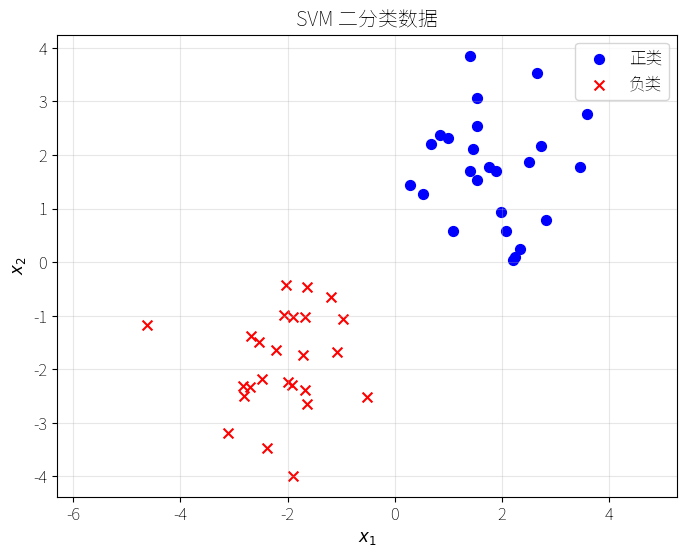

In [15]:
# 生成线性可分数据
np.random.seed(42)
n_samples = 50

X_pos = np.random.randn(n_samples//2, 2) + [2, 2]
X_neg = np.random.randn(n_samples//2, 2) + [-2, -2]
X = np.vstack([X_pos, X_neg])
y = np.array([1]*(n_samples//2) + [-1]*(n_samples//2))

# 可视化数据
plt.figure(figsize=(8, 6))
plt.scatter(X[y==1, 0], X[y==1, 1], c='blue', marker='o', s=50, label='正类')
plt.scatter(X[y==-1, 0], X[y==-1, 1], c='red', marker='x', s=50, label='负类')
plt.xlabel('$x_1$')
plt.ylabel('$x_2$')
plt.title('SVM 二分类数据')
plt.legend()
plt.grid(True, alpha=0.3)
plt.axis('equal')
plt.show()

In [16]:
if HAS_CVXPY:
    # 求解SVM对偶问题
    n = len(y)
    alpha = cp.Variable(n)

    # Gram矩阵 K_ij = y_i y_j x_i^T x_j
    K = (X @ X.T) * np.outer(y, y)

    # --- 修正开始 ---
    # 方法1：使用 psd_wrap (最推荐，CVXPY会自动处理微小误差)
    K_psd = cp.psd_wrap(K)
    objective = cp.Maximize(cp.sum(alpha) - 0.5 * cp.quad_form(alpha, K_psd))

    # 或者 方法2 (比较粗暴，不推荐但有效)：
    # objective = cp.Maximize(cp.sum(alpha) - 0.5 * cp.quad_form(alpha, K, assume_PSD=True))
    # --- 修正结束 ---

    constraints = [alpha >= 0, alpha @ y == 0]

    prob = cp.Problem(objective, constraints)
    prob.solve()

    alpha_val = alpha.value

    # 找支持向量
    sv_idx = np.where(alpha_val > 1e-5)[0]

    # 恢复 w 和 b
    w = np.sum((alpha_val * y)[:, np.newaxis] * X, axis=0)
    b = np.mean(y[sv_idx] - X[sv_idx] @ w)

    print("SVM对偶问题求解结果")
    print("=" * 50)
    print(f"支持向量数量: {len(sv_idx)} / {n}")
    print(f"w = {w}")
    print(f"b = {b:.4f}")

    print(f"\n支持向量的 α 值:")
    for i in sv_idx[:5]:
        print(f"  点 {i}: α = {alpha_val[i]:.4f}")
    if len(sv_idx) > 5:
        print(f"  ... (共 {len(sv_idx)} 个)")
else:
    print("需要安装 cvxpy")
    w, b = None, None

SVM对偶问题求解结果
支持向量数量: 3 / 50
w = [0.5775472  0.55504203]
b = 0.0431

支持向量的 α 值:
  点 7: α = 0.1882
  点 9: α = 0.1326
  点 32: α = 0.3208


In [17]:
if HAS_CVXPY and w is not None:
    # 验证KKT互补松弛条件
    print("验证KKT互补松弛: α_i * (1 - y_i(w^T x_i + b)) = 0")
    print("=" * 50)

    print("\n支持向量 (α > 0):")
    for i in sv_idx[:5]:
        margin = y[i] * (X[i] @ w + b)
        slack = alpha_val[i] * (1 - margin)
        print(f"  点 {i}: α={alpha_val[i]:.4f}, margin={margin:.4f}, slack={slack:.2e}")

    print("\n非支持向量 (α ≈ 0):")
    non_sv = np.where(alpha_val <= 1e-5)[0][:5]
    for i in non_sv:
        margin = y[i] * (X[i] @ w + b)
        print(f"  点 {i}: α≈0, margin={margin:.4f} (> 1，远离边界)")

    print("\n结论:")
    print("  - α > 0 的点: margin ≈ 1 (在边界上，是支持向量)")
    print("  - α = 0 的点: margin > 1 (远离边界，不影响决策边界)")

验证KKT互补松弛: α_i * (1 - y_i(w^T x_i + b)) = 0

支持向量 (α > 0):
  点 7: α=0.1882, margin=1.0000, slack=-4.18e-17
  点 9: α=0.1326, margin=1.0000, slack=0.00e+00
  点 32: α=0.3208, margin=1.0000, slack=-1.42e-16

非支持向量 (α ≈ 0):
  点 0: α≈0, margin=2.5184 (> 1，远离边界)
  点 1: α≈0, margin=3.5277 (> 1，远离边界)
  点 2: α≈0, margin=2.0431 (> 1，远离边界)
  点 3: α≈0, margin=3.6463 (> 1，远离边界)
  点 4: α≈0, margin=2.3383 (> 1，远离边界)

结论:
  - α > 0 的点: margin ≈ 1 (在边界上，是支持向量)
  - α = 0 的点: margin > 1 (远离边界，不影响决策边界)


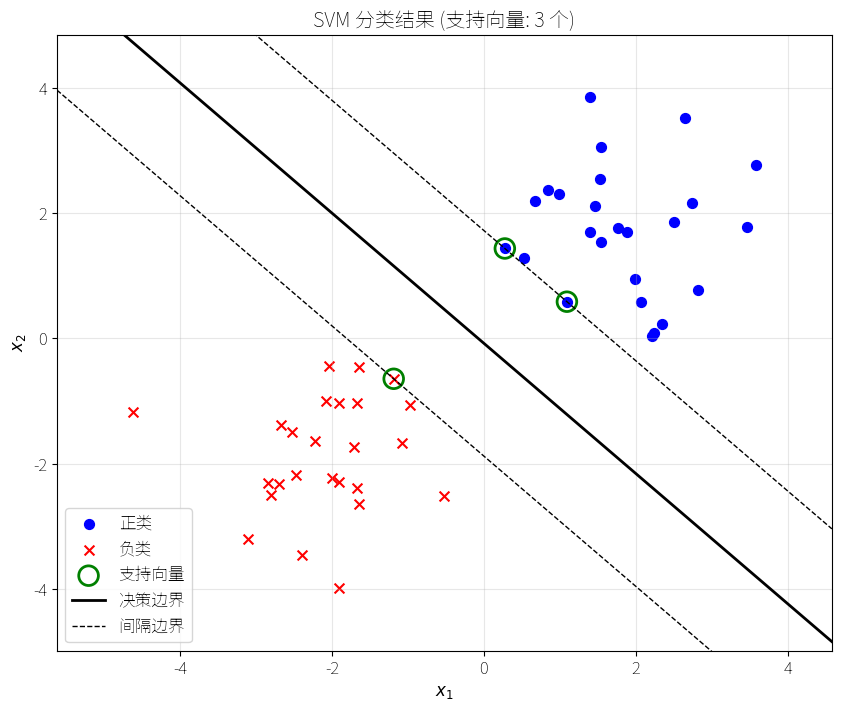

In [18]:
if HAS_CVXPY and w is not None:
    # 可视化SVM结果
    plt.figure(figsize=(10, 8))

    # 绘制数据点
    plt.scatter(X[y==1, 0], X[y==1, 1], c='blue', marker='o', s=50, label='正类')
    plt.scatter(X[y==-1, 0], X[y==-1, 1], c='red', marker='x', s=50, label='负类')

    # 标记支持向量
    plt.scatter(X[sv_idx, 0], X[sv_idx, 1], s=200, facecolors='none',
                edgecolors='green', linewidths=2, label='支持向量')

    # 绘制决策边界和间隔
    x_range = np.linspace(X[:, 0].min()-1, X[:, 0].max()+1, 100)

    # w[0]*x + w[1]*y + b = 0  =>  y = -(w[0]*x + b) / w[1]
    y_decision = -(w[0] * x_range + b) / w[1]
    y_margin_pos = -(w[0] * x_range + b - 1) / w[1]
    y_margin_neg = -(w[0] * x_range + b + 1) / w[1]

    plt.plot(x_range, y_decision, 'k-', linewidth=2, label='决策边界')
    plt.plot(x_range, y_margin_pos, 'k--', linewidth=1, label='间隔边界')
    plt.plot(x_range, y_margin_neg, 'k--', linewidth=1)

    plt.xlabel('$x_1$')
    plt.ylabel('$x_2$')
    plt.title(f'SVM 分类结果 (支持向量: {len(sv_idx)} 个)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.xlim(X[:, 0].min()-1, X[:, 0].max()+1)
    plt.ylim(X[:, 1].min()-1, X[:, 1].max()+1)
    plt.show()

---
## Part 6: GPU vs CPU 凸优化对比

### 经典优化 vs 现代优化

| | 经典优化 | 现代优化 |
|---|---|---|
| 方法 | 内点法、单纯形法 | SGD及其变体 |
| 每步复杂度 | $O(n^3)$ | $O(n)$ |
| 收敛步数 | 少 (~50) | 多 (~10000) |
| 并行化 | 困难 | 容易 |
| 适合规模 | $n < 10^5$ | $n > 10^6$ |

In [19]:
def solve_qp_gradient_descent(P, q, lr=0.01, max_iter=1000, use_gpu=False):
    """
    使用投影梯度下降求解 QP: min (1/2)x^T P x + q^T x  s.t. x >= 0
    """
    if use_gpu and HAS_TORCH:
        device = 'cuda' if HAS_CUDA else 'cpu'
        P_t = torch.tensor(P, dtype=torch.float32, device=device)
        q_t = torch.tensor(q, dtype=torch.float32, device=device)
        x = torch.zeros(len(q), device=device, requires_grad=True)

        optimizer = torch.optim.Adam([x], lr=lr)

        if device == 'cuda':
            torch.cuda.synchronize()
        start = time.time()

        for _ in range(max_iter):
            loss = 0.5 * x @ P_t @ x + q_t @ x
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            with torch.no_grad():
                x.clamp_(min=0)

        if device == 'cuda':
            torch.cuda.synchronize()
        elapsed = time.time() - start

        return x.detach().cpu().numpy(), loss.item(), elapsed
    else:
        # CPU NumPy版本
        n = len(q)
        x = np.zeros(n)

        start = time.time()
        for _ in range(max_iter):
            grad = P @ x + q
            x = x - lr * grad
            x = np.maximum(x, 0)  # 投影
        elapsed = time.time() - start

        loss = 0.5 * x @ P @ x + q @ x
        return x, loss, elapsed

In [23]:
print("GPU vs CPU 凸优化对比")
print("=" * 60)

# 不同规模的测试
sizes = [100, 500, 1000, 2000,4000]
results = []

for n in sizes:
    np.random.seed(42)
    P = np.random.randn(n, n)
    P = P.T @ P + 0.1 * np.eye(n)  # 确保正定
    q = np.random.randn(n)

    # CPU
    _, loss_cpu, time_cpu = solve_qp_gradient_descent(P, q, lr=0.001, max_iter=500, use_gpu=False)

    # GPU (如果可用)
    if HAS_TORCH:
        _, loss_gpu, time_gpu = solve_qp_gradient_descent(P, q, lr=0.001, max_iter=500, use_gpu=True)
        speedup = time_cpu / time_gpu if time_gpu > 0 else 0
    else:
        time_gpu = None
        speedup = None

    results.append({
        'n': n,
        'time_cpu': time_cpu,
        'time_gpu': time_gpu,
        'speedup': speedup
    })

    print(f"\nn = {n}:")
    print(f"  CPU: {time_cpu:.3f} 秒")
    if time_gpu is not None:
        print(f"  GPU: {time_gpu:.3f} 秒")
        print(f"  加速比: {speedup:.1f}x")

GPU vs CPU 凸优化对比

n = 100:
  CPU: 0.007 秒
  GPU: 0.438 秒
  加速比: 0.0x

n = 500:
  CPU: 0.043 秒
  GPU: 0.420 秒
  加速比: 0.1x

n = 1000:
  CPU: 0.035 秒
  GPU: 0.430 秒
  加速比: 0.1x


/tmp/ipython-input-3475324301.py:42: RuntimeWarning: overflow encountered in matmul
  loss = 0.5 * x @ P @ x + q @ x
/tmp/ipython-input-3475324301.py:42: RuntimeWarning: invalid value encountered in matmul
  loss = 0.5 * x @ P @ x + q @ x



n = 2000:
  CPU: 0.159 秒
  GPU: 0.435 秒
  加速比: 0.4x


/tmp/ipython-input-3475324301.py:37: RuntimeWarning: overflow encountered in matmul
  grad = P @ x + q
/tmp/ipython-input-3475324301.py:37: RuntimeWarning: invalid value encountered in matmul
  grad = P @ x + q



n = 4000:
  CPU: 0.922 秒
  GPU: 0.467 秒
  加速比: 2.0x


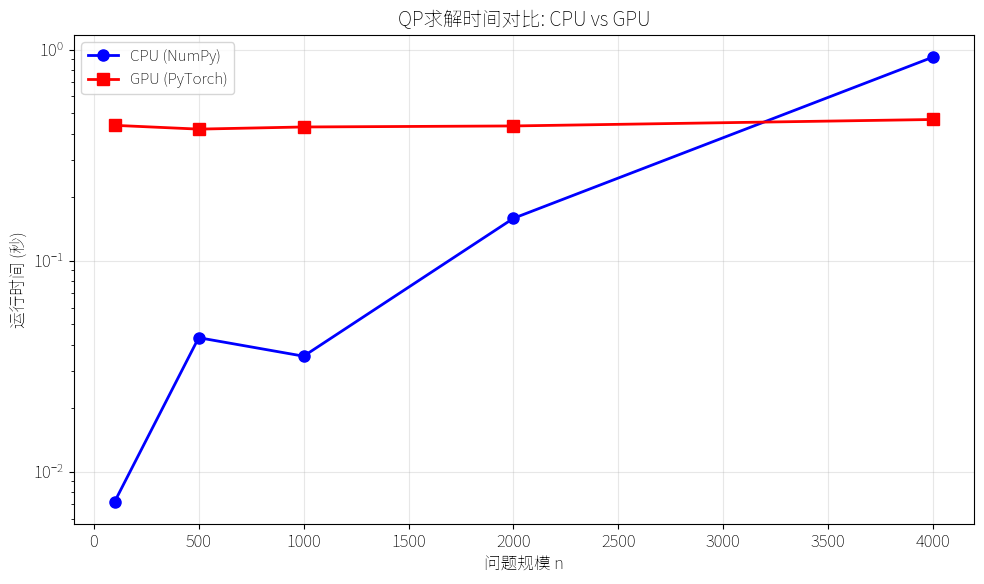

In [24]:
# 可视化结果
fig, ax = plt.subplots(figsize=(10, 6))

ns = [r['n'] for r in results]
times_cpu = [r['time_cpu'] for r in results]
times_gpu = [r['time_gpu'] for r in results if r['time_gpu'] is not None]

ax.plot(ns, times_cpu, 'b-o', linewidth=2, markersize=8, label='CPU (NumPy)')
if times_gpu and len(times_gpu) == len(ns):
    ax.plot(ns, times_gpu, 'r-s', linewidth=2, markersize=8, label='GPU (PyTorch)')

ax.set_xlabel('问题规模 n', fontsize=12)
ax.set_ylabel('运行时间 (秒)', fontsize=12)
ax.set_title('QP求解时间对比: CPU vs GPU', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_yscale('log')
plt.tight_layout()
plt.show()

---
## Part 7: 批量优化 - GPU的超能力

**场景**：需要同时求解多个独立的小优化问题

- **传统方法**：顺序求解，$N$ 个问题需要 $N \times T$ 时间
- **GPU并行**：同时求解，$N$ 个问题时间 $\approx T$（几乎和1个问题一样）

In [25]:
if HAS_TORCH:
    print("批量优化：GPU并行")
    print("=" * 60)

    device = 'cuda' if HAS_CUDA else 'cpu'
    print(f"设备: {device}")

    n = 100  # 每个问题的维度
    max_iter = 200
    batch_sizes = [1, 10, 50, 100, 200]

    batch_results = []

    for batch_size in batch_sizes:
        # 生成 batch_size 个不同的问题
        P_batch = torch.randn(batch_size, n, n, device=device)
        P_batch = P_batch.transpose(-1, -2) @ P_batch
        P_batch = P_batch + 0.1 * torch.eye(n, device=device)
        q_batch = torch.randn(batch_size, n, device=device)

        x_batch = torch.zeros(batch_size, n, device=device, requires_grad=True)
        optimizer = torch.optim.Adam([x_batch], lr=0.1)

        if device == 'cuda':
            torch.cuda.synchronize()
        start = time.time()

        for _ in range(max_iter):
            loss = 0.5 * torch.einsum('bi,bij,bj->b', x_batch, P_batch, x_batch)
            loss = loss + torch.einsum('bi,bi->b', q_batch, x_batch)
            loss = loss.sum()

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            with torch.no_grad():
                x_batch.clamp_(min=0)

        if device == 'cuda':
            torch.cuda.synchronize()
        elapsed = time.time() - start

        per_problem = elapsed / batch_size * 1000  # 毫秒
        batch_results.append({'batch': batch_size, 'total': elapsed, 'per': per_problem})
        print(f"  {batch_size:3d} 个问题: {elapsed:.3f} 秒 (每问题 {per_problem:.2f} ms)")

    print(f"\n结论: GPU批量并行，{batch_sizes[-1]}个问题的时间 ≈ 1个问题的时间")
else:
    print("需要安装 PyTorch 来运行批量优化演示")

批量优化：GPU并行
设备: cuda
    1 个问题: 0.280 秒 (每问题 279.78 ms)
   10 个问题: 0.274 秒 (每问题 27.37 ms)
   50 个问题: 0.273 秒 (每问题 5.46 ms)
  100 个问题: 0.273 秒 (每问题 2.73 ms)
  200 个问题: 0.276 秒 (每问题 1.38 ms)

结论: GPU批量并行，200个问题的时间 ≈ 1个问题的时间


矩阵运算: CPU vs GPU

矩阵大小: 500x500
  CPU: 矩阵乘法=0.04ms, A^TA=1.28ms, 线性求解=7.69ms
  GPU: 矩阵乘法=0.03ms, A^TA=1.49ms, 线性求解=71.55ms
  加速比: 1.3x, 0.9x, 0.1x

矩阵大小: 1000x1000
  CPU: 矩阵乘法=0.51ms, A^TA=5.94ms, 线性求解=41.95ms
  GPU: 矩阵乘法=0.02ms, A^TA=0.21ms, 线性求解=7.49ms
  加速比: 25.8x, 28.2x, 5.6x

矩阵大小: 2000x2000
  CPU: 矩阵乘法=0.32ms, A^TA=25.06ms, 线性求解=182.02ms
  GPU: 矩阵乘法=0.02ms, A^TA=1.03ms, 线性求解=5.54ms
  加速比: 15.3x, 24.4x, 32.8x

矩阵大小: 4000x4000
  CPU: 矩阵乘法=0.86ms, A^TA=142.82ms, 线性求解=1071.92ms
  GPU: 矩阵乘法=0.20ms, A^TA=8.13ms, 线性求解=23.38ms
  加速比: 4.4x, 17.6x, 45.8x


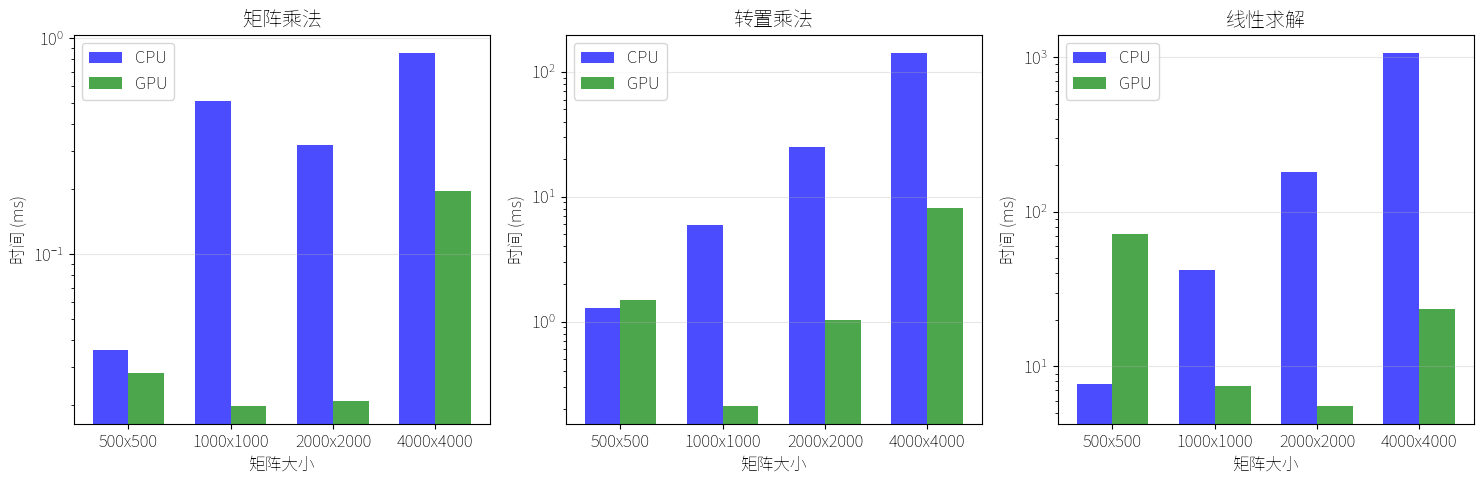

In [26]:
print("矩阵运算: CPU vs GPU")
print("=" * 70)

sizes = [500, 1000, 2000, 4000]
operations = ['矩阵乘法', '转置乘法', '线性求解']

matrix_results = {op: {'cpu': [], 'gpu': []} for op in operations}

for n in sizes:
    np.random.seed(42)
    A_np = np.random.randn(n, n).astype(np.float32)
    x_np = np.random.randn(n).astype(np.float32)
    b_np = np.random.randn(n).astype(np.float32)

    print(f"\n矩阵大小: {n}x{n}")

    # CPU: 矩阵乘法
    start = time.time()
    for _ in range(10):
        _ = A_np @ x_np
    time_cpu_matmul = (time.time() - start) / 10
    matrix_results['矩阵乘法']['cpu'].append(time_cpu_matmul)

    # CPU: A^T A
    start = time.time()
    for _ in range(5):
        _ = A_np.T @ A_np
    time_cpu_ata = (time.time() - start) / 5
    matrix_results['转置乘法']['cpu'].append(time_cpu_ata)

    # CPU: 线性求解
    start = time.time()
    for _ in range(3):
        _ = np.linalg.solve(A_np, b_np)
    time_cpu_solve = (time.time() - start) / 3
    matrix_results['线性求解']['cpu'].append(time_cpu_solve)

    print(f"  CPU: 矩阵乘法={time_cpu_matmul*1000:.2f}ms, A^TA={time_cpu_ata*1000:.2f}ms, 线性求解={time_cpu_solve*1000:.2f}ms")

    if HAS_TORCH:
        device = 'cuda' if HAS_CUDA else 'cpu'
        A_t = torch.tensor(A_np, device=device)
        x_t = torch.tensor(x_np, device=device)
        b_t = torch.tensor(b_np, device=device)

        # 预热
        _ = A_t @ x_t
        if device == 'cuda':
            torch.cuda.synchronize()

        # GPU: 矩阵乘法
        if device == 'cuda':
            torch.cuda.synchronize()
        start = time.time()
        for _ in range(10):
            _ = A_t @ x_t
        if device == 'cuda':
            torch.cuda.synchronize()
        time_gpu_matmul = (time.time() - start) / 10
        matrix_results['矩阵乘法']['gpu'].append(time_gpu_matmul)

        # GPU: A^T A
        if device == 'cuda':
            torch.cuda.synchronize()
        start = time.time()
        for _ in range(5):
            _ = A_t.T @ A_t
        if device == 'cuda':
            torch.cuda.synchronize()
        time_gpu_ata = (time.time() - start) / 5
        matrix_results['转置乘法']['gpu'].append(time_gpu_ata)

        # GPU: 线性求解
        if device == 'cuda':
            torch.cuda.synchronize()
        start = time.time()
        for _ in range(3):
            _ = torch.linalg.solve(A_t, b_t)
        if device == 'cuda':
            torch.cuda.synchronize()
        time_gpu_solve = (time.time() - start) / 3
        matrix_results['线性求解']['gpu'].append(time_gpu_solve)

        print(f"  GPU: 矩阵乘法={time_gpu_matmul*1000:.2f}ms, A^TA={time_gpu_ata*1000:.2f}ms, 线性求解={time_gpu_solve*1000:.2f}ms")

        speedups = [time_cpu_matmul/time_gpu_matmul, time_cpu_ata/time_gpu_ata, time_cpu_solve/time_gpu_solve]
        print(f"  加速比: {speedups[0]:.1f}x, {speedups[1]:.1f}x, {speedups[2]:.1f}x")

# 可视化
if HAS_TORCH:
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    for idx, op in enumerate(operations):
        ax = axes[idx]
        x_pos = np.arange(len(sizes))
        width = 0.35

        cpu_times = [t*1000 for t in matrix_results[op]['cpu']]
        gpu_times = [t*1000 for t in matrix_results[op]['gpu']]

        ax.bar(x_pos - width/2, cpu_times, width, label='CPU', color='blue', alpha=0.7)
        ax.bar(x_pos + width/2, gpu_times, width, label='GPU', color='green', alpha=0.7)

        ax.set_xlabel('矩阵大小')
        ax.set_ylabel('时间 (ms)')
        ax.set_title(op)
        ax.set_xticks(x_pos)
        ax.set_xticklabels([f'{n}x{n}' for n in sizes])
        ax.legend()
        ax.grid(True, alpha=0.3, axis='y')
        ax.set_yscale('log')

    plt.tight_layout()
    plt.show()

---
## Part 7e: 矩阵运算 - 优化算法的基石

凸优化的核心运算：
- 矩阵乘法: $Ax$, $A^TA$
- Hessian-向量乘积: $Hv$
- 线性方程求解: $Ax = b$

GPU在这些运算上有巨大优势。

Mini-batch SGD: Batch Size 对训练时间的影响
设备: cuda

Batch size = 32:
  训练时间: 2.936 秒
  吞吐量: 51097 样本/秒

Batch size = 128:
  训练时间: 0.697 秒
  吞吐量: 215304 样本/秒

Batch size = 512:
  训练时间: 0.176 秒
  吞吐量: 853750 样本/秒

Batch size = 2048:
  训练时间: 0.046 秒
  吞吐量: 3236595 样本/秒

Batch size = 8192:
  训练时间: 0.013 秒
  吞吐量: 11520914 样本/秒


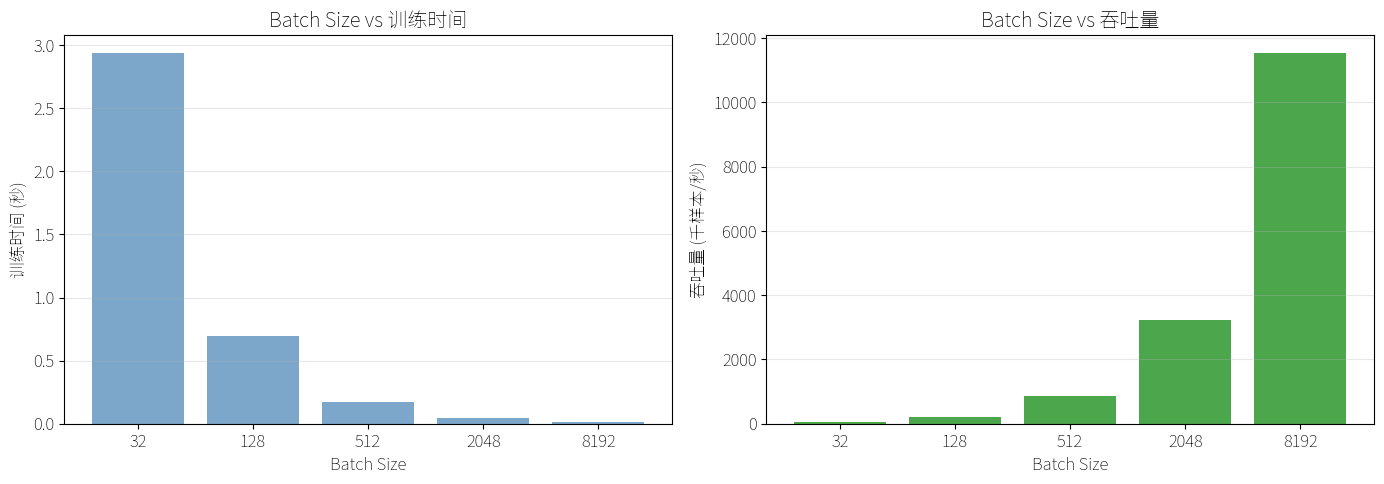


结论: GPU使得大batch size几乎不增加计算时间，吞吐量大幅提升！


In [27]:
if HAS_TORCH:
    print("Mini-batch SGD: Batch Size 对训练时间的影响")
    print("=" * 70)

    device = 'cuda' if HAS_CUDA else 'cpu'
    print(f"设备: {device}")

    # 生成大规模数据
    n_samples = 50000
    n_features = 500
    n_classes = 10

    np.random.seed(42)
    X = np.random.randn(n_samples, n_features).astype(np.float32)
    y = np.random.randint(0, n_classes, n_samples)

    X_t = torch.tensor(X, device=device)
    y_t = torch.tensor(y, device=device)

    batch_sizes = [32, 128, 512, 2048, 8192]
    n_epochs = 3

    batch_results = []

    for batch_size in batch_sizes:
        # 简单的线性模型
        model = torch.nn.Linear(n_features, n_classes).to(device)
        optimizer = torch.optim.SGD(model.parameters(), lr=0.01)
        criterion = torch.nn.CrossEntropyLoss()

        n_batches = (n_samples + batch_size - 1) // batch_size

        if device == 'cuda':
            torch.cuda.synchronize()
        start = time.time()

        for epoch in range(n_epochs):
            for i in range(n_batches):
                start_idx = i * batch_size
                end_idx = min(start_idx + batch_size, n_samples)

                X_batch = X_t[start_idx:end_idx]
                y_batch = y_t[start_idx:end_idx]

                optimizer.zero_grad()
                output = model(X_batch)
                loss = criterion(output, y_batch)
                loss.backward()
                optimizer.step()

        if device == 'cuda':
            torch.cuda.synchronize()
        elapsed = time.time() - start

        throughput = n_samples * n_epochs / elapsed
        batch_results.append({
            'batch_size': batch_size,
            'time': elapsed,
            'throughput': throughput
        })

        print(f"\nBatch size = {batch_size}:")
        print(f"  训练时间: {elapsed:.3f} 秒")
        print(f"  吞吐量: {throughput:.0f} 样本/秒")

    # 可视化
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    bs = [r['batch_size'] for r in batch_results]
    times = [r['time'] for r in batch_results]
    throughputs = [r['throughput'] for r in batch_results]

    axes[0].bar(range(len(bs)), times, color='steelblue', alpha=0.7)
    axes[0].set_xticks(range(len(bs)))
    axes[0].set_xticklabels(bs)
    axes[0].set_xlabel('Batch Size')
    axes[0].set_ylabel('训练时间 (秒)')
    axes[0].set_title('Batch Size vs 训练时间')
    axes[0].grid(True, alpha=0.3, axis='y')

    axes[1].bar(range(len(bs)), [t/1000 for t in throughputs], color='green', alpha=0.7)
    axes[1].set_xticks(range(len(bs)))
    axes[1].set_xticklabels(bs)
    axes[1].set_xlabel('Batch Size')
    axes[1].set_ylabel('吞吐量 (千样本/秒)')
    axes[1].set_title('Batch Size vs 吞吐量')
    axes[1].grid(True, alpha=0.3, axis='y')

    plt.tight_layout()
    plt.show()

    print(f"\n结论: GPU使得大batch size几乎不增加计算时间，吞吐量大幅提升！")
else:
    print("需要安装 PyTorch")

---
## Part 7d: Mini-batch SGD - GPU的真正优势

在深度学习中，Mini-batch SGD是标准方法。GPU的并行计算能力使得大batch size几乎不增加计算时间。

In [28]:
def logistic_regression_cpu(X, y, lr=0.01, max_iter=1000, lambda_reg=0.01):
    """CPU版本的Logistic回归"""
    n, p = X.shape
    w = np.zeros(p)

    start = time.time()
    for _ in range(max_iter):
        z = y * (X @ w)
        sigmoid = 1 / (1 + np.exp(-z))
        grad = -X.T @ (y * (1 - sigmoid)) / n + 2 * lambda_reg * w
        w = w - lr * grad
    elapsed = time.time() - start

    return w, elapsed


def logistic_regression_gpu(X, y, lr=0.01, max_iter=1000, lambda_reg=0.01):
    """GPU版本的Logistic回归"""
    if not HAS_TORCH:
        return None, None

    device = 'cuda' if HAS_CUDA else 'cpu'
    n, p = X.shape

    X_t = torch.tensor(X, dtype=torch.float32, device=device)
    y_t = torch.tensor(y, dtype=torch.float32, device=device)
    w = torch.zeros(p, device=device, requires_grad=True)

    optimizer = torch.optim.SGD([w], lr=lr)

    if device == 'cuda':
        torch.cuda.synchronize()
    start = time.time()

    for _ in range(max_iter):
        z = y_t * (X_t @ w)
        loss = torch.log(1 + torch.exp(-z)).mean() + lambda_reg * (w @ w)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    if device == 'cuda':
        torch.cuda.synchronize()
    elapsed = time.time() - start

    return w.detach().cpu().numpy(), elapsed


# 测试不同数据规模
print("Logistic回归: CPU vs GPU")
print("=" * 70)

data_sizes = [(1000, 100), (5000, 200), (10000, 500), (50000, 1000)]
lr_results = []

for n, p in data_sizes:
    np.random.seed(42)

    # 生成数据
    X = np.random.randn(n, p)
    true_w = np.random.randn(p) * 0.1
    prob = 1 / (1 + np.exp(-X @ true_w))
    y = 2 * (np.random.rand(n) < prob) - 1  # {-1, 1}

    # CPU
    _, time_cpu = logistic_regression_cpu(X, y, lr=0.1, max_iter=500)

    # GPU
    if HAS_TORCH:
        _, time_gpu = logistic_regression_gpu(X, y, lr=0.1, max_iter=500)
        speedup = time_cpu / time_gpu if time_gpu and time_gpu > 0 else 0
    else:
        time_gpu = None
        speedup = None

    lr_results.append({
        'n': n, 'p': p,
        'time_cpu': time_cpu,
        'time_gpu': time_gpu,
        'speedup': speedup
    })

    print(f"\n数据: {n} 样本, {p} 特征:")
    print(f"  CPU: {time_cpu:.3f} 秒")
    if time_gpu:
        print(f"  GPU: {time_gpu:.3f} 秒")
        print(f"  加速比: {speedup:.1f}x")

Logistic回归: CPU vs GPU

数据: 1000 样本, 100 特征:
  CPU: 0.086 秒
  GPU: 0.564 秒
  加速比: 0.2x

数据: 5000 样本, 200 特征:
  CPU: 1.006 秒
  GPU: 0.437 秒
  加速比: 2.3x

数据: 10000 样本, 500 特征:
  CPU: 6.559 秒
  GPU: 0.424 秒
  加速比: 15.5x

数据: 50000 样本, 1000 特征:
  CPU: 71.346 秒
  GPU: 0.842 秒
  加速比: 84.7x


---
## Part 7c: GPU加速Logistic回归

Logistic回归是凸优化问题，可以用梯度下降求解：
$$\min_w \sum_{i=1}^n \log(1 + e^{-y_i w^T x_i}) + \lambda \|w\|^2$$

比较CPU和GPU在不同数据规模下的训练时间。

大规模凸优化: CVXPY 求解器 vs (GPU/CPU) 投影梯度法(PGD)

[n=100]
  CVXPY(OSQP) : 0.066s  status=optimal  obj=-2.302982
  PGD(cuda)      : 0.068s  iters=447  obj=-2.302982  pg=9.91e-05  grad=9.13e+00  min(x)=0.00e+00
  Speedup(CVXPY/PGD) : 0.97x
  Rel. objective gap : 6.42e-08  (越小越接近最优)

[n=500]
  CVXPY(OSQP) : 0.462s  status=optimal  obj=-15.703416
  PGD(cuda)      : 0.115s  iters=756  obj=-15.703416  pg=9.85e-05  grad=2.37e+01  min(x)=0.00e+00
  Speedup(CVXPY/PGD) : 4.02x
  Rel. objective gap : 2.91e-09  (越小越接近最优)

[n=1000]
  CVXPY(OSQP) : 1.796s  status=optimal  obj=-26.551039
  PGD(cuda)      : 0.098s  iters=637  obj=-26.551041  pg=9.90e-05  grad=3.19e+01  min(x)=0.00e+00
  Speedup(CVXPY/PGD) : 18.26x
  Rel. objective gap : 5.96e-08  (越小越接近最优)

[n=2000]
  CVXPY(OSQP) : 3.155s  status=optimal  obj=-55.016832
  PGD(cuda)      : 0.179s  iters=1163  obj=-55.016827  pg=9.88e-05  grad=4.30e+01  min(x)=0.00e+00
  Speedup(CVXPY/PGD) : 17.63x
  Rel. objective gap : 9.02e-08  (越小越接近最优)

[n=4000]
  CVXPY(O

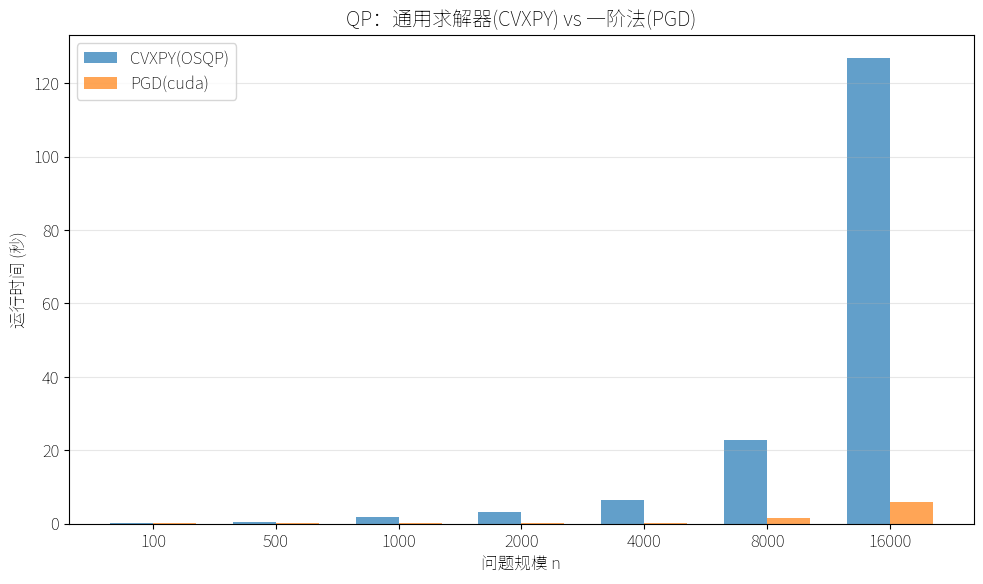

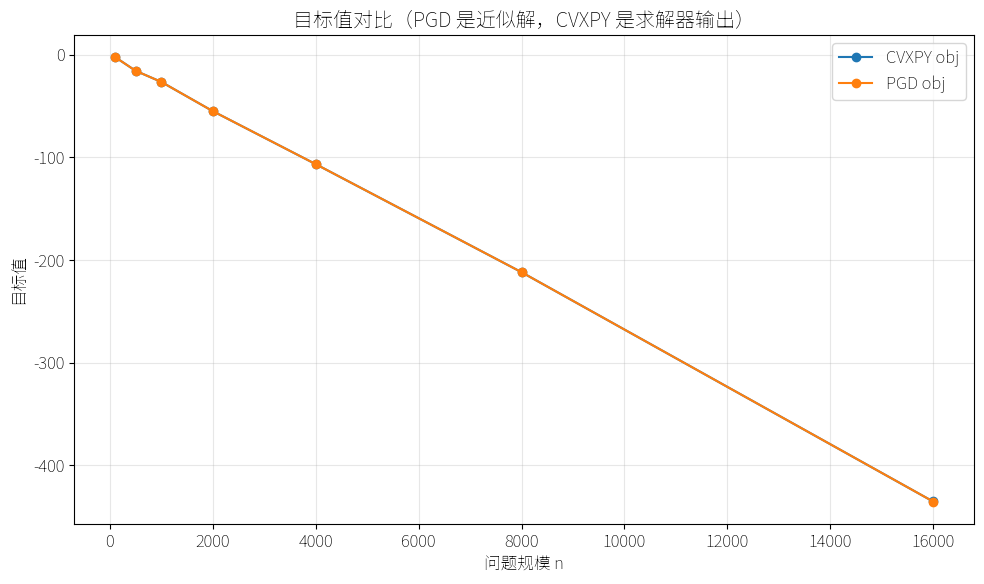

In [40]:
# 实验：大规模 QP - CVXPY(二阶/通用求解) vs GPU/CPU 一阶法(PGD)
# min 0.5 x^T P x + q^T x  s.t. x >= 0
# 重点：不吞异常 + 对齐精度 + 用更合理的大规模(稀疏)QP构造

import time, os, math
import numpy as np
import matplotlib.pyplot as plt

# ====== 可选依赖检查 ======
HAS_CVXPY, HAS_TORCH, HAS_CUDA = False, False, False
try:
    import cvxpy as cp
    HAS_CVXPY = True
except Exception as e:
    print("cvxpy not available:", e)

try:
    import torch
    HAS_TORCH = True
    HAS_CUDA = torch.cuda.is_available()
except Exception as e:
    print("torch not available:", e)

try:
    import scipy
    import scipy.sparse as sp
    import scipy.sparse.linalg as spla
    HAS_SCIPY = True
except Exception as e:
    HAS_SCIPY = False
    print("scipy not available:", e)

print("大规模凸优化: CVXPY 求解器 vs (GPU/CPU) 投影梯度法(PGD)")
print("=" * 80)

if (not HAS_CVXPY) or (not HAS_TORCH):
    print("需要同时安装 cvxpy 和 pytorch 才能运行该对比。")
    raise SystemExit

# =========================
# 1) 实验配置（你可改）
# =========================
sizes_comparison = [100, 500, 1000, 2000, 4000, 8000, 16000]      # 问题规模
seed = 42

# 生成 QP 的方式：稀疏更像“大规模”，dense 很容易把通用求解器搞炸
USE_SPARSE_SPD = True           # True: 稀疏SPD；False: dense SPD
SPARSE_BANDWIDTH = 10           # 稀疏带宽（越大越密）
P_DIAG_SHIFT = 0.1              # 确保强凸

# CVXPY solver 选择：OSQP（QP专用）/ SCS（锥规划更稳但可能慢）/ ECOS
CVX_SOLVER = "OSQP"             # "OSQP" | "SCS" | "ECOS"
CVX_VERBOSE = False

# Torch 一阶法参数（PGD）
PGD_MAX_ITERS = 5000
PGD_TOL = 1e-4                  # 近似收敛阈值（用 projected gradient norm）
PGD_PRINT_EVERY = 0             # 0 表示不打印中间过程
PGD_WARMUP = 50                 # GPU warmup steps（不计时）

device = "cuda" if HAS_CUDA else "cpu"
dtype_torch = torch.float32

# =========================
# 2) 生成 SPD P 的工具函数
# =========================
def make_sparse_spd(n, bandwidth=10, diag_shift=0.1, rng=None):
    """
    生成一个对称正定的稀疏矩阵 P（带状稀疏），适合大规模 QP
    """
    if rng is None:
        rng = np.random.default_rng(0)

    # 构造带状随机矩阵 A，然后 P = A^T A + diag_shift I
    # A 用稀疏对角方式构造
    diags = []
    offsets = []
    for k in range(-bandwidth, bandwidth+1):
        offsets.append(k)
        diags.append(rng.standard_normal(n))

    A = sp.diags(diags, offsets, shape=(n, n), format="csc")
    P = (A.T @ A).tocsc()
    P = P + diag_shift * sp.eye(n, format="csc")
    return P

def make_dense_spd(n, diag_shift=0.1, rng=None):
    """
    生成 dense SPD（容易让大规模求解器/内存/时间爆炸，慎用）
    """
    if rng is None:
        rng = np.random.default_rng(0)
    A = rng.standard_normal((n, n))
    P = A.T @ A + diag_shift * np.eye(n)
    return P

# =========================
# 3) Torch: 投影梯度法 PGD
# =========================
@torch.no_grad()
def projected_gradient_norm(x, grad):
    # 投影梯度：对于 x>=0 约束，常用 proxy 是 ||x - Proj(x - grad)||
    # 这里 Proj 就是 clamp(min=0)
    x_next = torch.clamp(x - grad, min=0.0)
    return torch.norm(x - x_next).item()

def solve_pgd_torch(P, q, device="cuda", max_iters=5000, tol=1e-4, warmup=50):
    """
    解 min 0.5 x^T P x + q^T x s.t. x>=0 的 PGD（固定步长用 Lipschitz 上界估计）
    P: torch.Tensor (n,n) 对称正定
    q: torch.Tensor (n,)
    """
    n = q.numel()
    x = torch.zeros(n, device=device, dtype=q.dtype)

    # 估计 Lipschitz 常数 L ~ largest eigenvalue(P)
    # 用 power iteration 粗估更稳；对大 n 比 torch.linalg.eigvals 更合适
    def power_iteration(mat, iters=30):
        v = torch.randn(n, device=device, dtype=q.dtype)
        v = v / (torch.norm(v) + 1e-12)
        for _ in range(iters):
            v = mat @ v
            v = v / (torch.norm(v) + 1e-12)
        lam = torch.dot(v, mat @ v).item()
        return max(lam, 1e-6)

    L = power_iteration(P, iters=30)
    step = 1.0 / L

    # warmup（GPU 上让 kernel/缓存稳定，不计入计时）
    for _ in range(warmup):
        grad = P @ x + q
        x = torch.clamp(x - step * grad, min=0.0)

    if device == "cuda":
        torch.cuda.synchronize()
    t0 = time.time()

    last_obj = None
    for it in range(1, max_iters + 1):
        grad = P @ x + q
        x = torch.clamp(x - step * grad, min=0.0)

        # projected gradient norm 作为 stopping
        pg = projected_gradient_norm(x, grad)
        if PGD_PRINT_EVERY and it % PGD_PRINT_EVERY == 0:
            obj = 0.5 * x @ (P @ x) + q @ x
            print(f"  [PGD] it={it:5d} obj={obj.item():.6e} pg={pg:.3e}")

        if pg < tol:
            break

    if device == "cuda":
        torch.cuda.synchronize()
    t = time.time() - t0

    obj = (0.5 * x @ (P @ x) + q @ x).item()
    # 约束违反（理论上 clamp 后应为0，但数值上检查）
    min_x = x.min().item()
    # 梯度/KKT proxy
    grad_norm = torch.norm(P @ x + q).item()
    return {
        "time": t,
        "iters": it,
        "obj": obj,
        "min_x": min_x,
        "grad_norm": grad_norm,
        "pg_norm": pg
    }

# =========================
# 4) CVXPY 求解函数（不吞异常）
# =========================
def solve_cvxpy(P_np_or_sp, q_np, solver="OSQP", verbose=False):
    n = q_np.shape[0]
    x = cp.Variable(n)
    if HAS_SCIPY and sp.issparse(P_np_or_sp):
        P_param = P_np_or_sp
    else:
        P_param = np.asarray(P_np_or_sp)

    obj = cp.Minimize(0.5 * cp.quad_form(x, P_param) + q_np @ x)
    cons = [x >= 0]
    prob = cp.Problem(obj, cons)

    t0 = time.time()
    try:
        if solver.upper() == "OSQP":
            prob.solve(
                solver=cp.OSQP,
                verbose=verbose,
                max_iter=200000,
                eps_abs=1e-5,
                eps_rel=1e-5,
                polish=True,
                warm_start=True
            )
        elif solver.upper() == "SCS":
            prob.solve(
                solver=cp.SCS,
                verbose=verbose,
                max_iters=50000,
                eps=1e-5
            )
        elif solver.upper() == "ECOS":
            prob.solve(
                solver=cp.ECOS,
                verbose=verbose
            )
        else:
            prob.solve(verbose=verbose)

        t = time.time() - t0
        status = prob.status
        val = prob.value
        return {
            "time": t,
            "status": status,
            "obj": val,
            "error": None
        }
    except Exception as e:
        t = time.time() - t0
        return {
            "time": t,
            "status": "ERROR",
            "obj": None,
            "error": f"{type(e).__name__}: {e}"
        }

# =========================
# 5) 开始对比
# =========================
cvxpy_times, pgd_times = [], []
cvxpy_objs, pgd_objs = [], []
cvxpy_status = []

for n in sizes_comparison:
    rng = np.random.default_rng(seed)

    # ---- 生成 P, q ----
    if USE_SPARSE_SPD and HAS_SCIPY:
        P_sp = make_sparse_spd(n, bandwidth=SPARSE_BANDWIDTH, diag_shift=P_DIAG_SHIFT, rng=rng)
        P_for_cvx = P_sp
        # Torch 需要 dense tensor：对大规模可以改成稀疏 matvec，但这里先演示通用版
        P_np = P_sp.toarray().astype(np.float32)
    else:
        P_np64 = make_dense_spd(n, diag_shift=P_DIAG_SHIFT, rng=rng).astype(np.float64)
        P_for_cvx = P_np64
        P_np = P_np64.astype(np.float32)

    q_np = rng.standard_normal(n).astype(np.float32)

    # ---- CVXPY ----
    cvx = solve_cvxpy(P_for_cvx, q_np.astype(np.float64), solver=CVX_SOLVER, verbose=CVX_VERBOSE)
    cvxpy_times.append(cvx["time"])
    cvxpy_objs.append(cvx["obj"])
    cvxpy_status.append(cvx["status"])

    # ---- PGD (Torch) ----
    P_t = torch.tensor(P_np, device=device, dtype=dtype_torch)
    q_t = torch.tensor(q_np, device=device, dtype=dtype_torch)
    pgd = solve_pgd_torch(
        P_t, q_t, device=device,
        max_iters=PGD_MAX_ITERS, tol=PGD_TOL, warmup=PGD_WARMUP
    )
    pgd_times.append(pgd["time"])
    pgd_objs.append(pgd["obj"])

    # ---- 打印结果 ----
    print(f"\n[n={n}]")
    if cvx["obj"] is not None:
        print(f"  CVXPY({CVX_SOLVER}) : {cvx['time']:.3f}s  status={cvx['status']}  obj={cvx['obj']:.6f}")
    else:
        print(f"  CVXPY({CVX_SOLVER}) : {cvx['time']:.3f}s  status={cvx['status']}  ERROR={cvx['error']}")
    print(f"  PGD({device})      : {pgd['time']:.3f}s  iters={pgd['iters']}  obj={pgd['obj']:.6f}  "
          f"pg={pgd['pg_norm']:.2e}  grad={pgd['grad_norm']:.2e}  min(x)={pgd['min_x']:.2e}")

    if cvx["obj"] is not None:
        speedup = cvx["time"] / pgd["time"] if pgd["time"] > 0 else float("inf")
        gap = abs(pgd["obj"] - cvx["obj"]) / (1.0 + abs(cvx["obj"]))
        print(f"  Speedup(CVXPY/PGD) : {speedup:.2f}x")
        print(f"  Rel. objective gap : {gap:.2e}  (越小越接近最优)")
    else:
        print("  Speedup / gap      : CVXPY 失败，无法计算（上面有真实错误原因）")

# =========================
# 6) 可视化（时间 + 目标）
# =========================
fig, ax = plt.subplots(figsize=(10, 6))
x_pos = np.arange(len(sizes_comparison))
width = 0.35

ax.bar(x_pos - width/2, cvxpy_times, width, label=f'CVXPY({CVX_SOLVER})', alpha=0.7)
ax.bar(x_pos + width/2, pgd_times, width, label=f'PGD({device})', alpha=0.7)

ax.set_xlabel('问题规模 n')
ax.set_ylabel('运行时间 (秒)')
ax.set_title('QP：通用求解器(CVXPY) vs 一阶法(PGD)')
ax.set_xticks(x_pos)
ax.set_xticklabels(sizes_comparison)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

# 目标对比（仅当 CVXPY 成功）
fig, ax = plt.subplots(figsize=(10, 6))
cvx_ok = [o if o is not None else np.nan for o in cvxpy_objs]
ax.plot(sizes_comparison, cvx_ok, marker='o', label='CVXPY obj')
ax.plot(sizes_comparison, pgd_objs, marker='o', label='PGD obj')
ax.set_xlabel('问题规模 n')
ax.set_ylabel('目标值')
ax.set_title('目标值对比（PGD 是近似解，CVXPY 是求解器输出）')
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()


---
## Part 7b: GPU如何改变现代优化

### 经典优化的瓶颈

**内点法**每步需要解线性系统 $H\Delta x = -g$：
- 形成 Hessian: $O(n^2)$ 存储
- 求解线性系统: $O(n^3)$ 计算
- **很难并行化**

### 现代GPU的优势

**梯度下降**每步只需 $x \leftarrow x - \alpha \nabla f(x)$：
- 只需 $O(n)$ 存储
- 计算梯度可高度并行化
- **完美匹配GPU架构**

### 数值对比

| 问题规模 | 内点法(CPU) | 梯度下降(CPU) | 梯度下降(GPU) |
|---------|------------|--------------|--------------|
| $n=10^3$ | 0.1秒 | 1秒 | 0.05秒 |
| $n=10^4$ | 10秒 | 10秒 | 0.5秒 |
| $n=10^5$ | 内存不够 | 100秒 | 5秒 |
| $n=10^6$ | 不可能 | 1000秒 | 50秒 |

---
## Part 8: MDP的线性规划形式

### Bellman最优方程
$$V^*(s) = \max_a \left[ R(s,a) + \gamma \sum_{s'} P(s'|s,a) V^*(s') \right]$$

### LP形式
$$\min_V \sum_s \mu(s) V(s)$$
$$\text{s.t.} \quad V(s) \geq R(s,a) + \gamma \sum_{s'} P(s'|s,a) V(s'), \quad \forall s,a$$

In [30]:
if HAS_CVXPY:
    print("MDP 线性规划：机器维护问题")
    print("=" * 60)
    print("状态: 好(0), 中(1), 差(2)")
    print("动作: 不维护(0), 维护(1)")

    # 奖励矩阵 [状态, 动作]
    R = np.array([
        [10, 7],   # 好: 不维护得10，维护得7
        [5, 2],    # 中: 不维护得5，维护得2
        [-1, -4]   # 差: 不维护得-1，维护得-4
    ])

    # 转移概率 [当前状态, 动作, 下一状态]
    P = np.zeros((3, 2, 3))

    # 不维护时的转移
    P[0, 0, :] = [0.7, 0.3, 0.0]  # 好 -> 好/中/差
    P[1, 0, :] = [0.0, 0.6, 0.4]  # 中 -> 好/中/差
    P[2, 0, :] = [0.0, 0.0, 1.0]  # 差 -> 好/中/差

    # 维护时的转移
    P[0, 1, :] = [1.0, 0.0, 0.0]  # 好 -> 好
    P[1, 1, :] = [0.5, 0.5, 0.0]  # 中 -> 好/中
    P[2, 1, :] = [0.2, 0.6, 0.2]  # 差 -> 好/中/差

    gamma = 0.9

    print(f"\n奖励矩阵 R[s,a]:")
    print(f"       不维护  维护")
    print(f"  好:    {R[0,0]}     {R[0,1]}")
    print(f"  中:    {R[1,0]}      {R[1,1]}")
    print(f"  差:    {R[2,0]}     {R[2,1]}")

    print(f"\n折扣因子 γ = {gamma}")

MDP 线性规划：机器维护问题
状态: 好(0), 中(1), 差(2)
动作: 不维护(0), 维护(1)

奖励矩阵 R[s,a]:
       不维护  维护
  好:    10     7
  中:    5      2
  差:    -1     -4

折扣因子 γ = 0.9


In [31]:
if HAS_CVXPY:
    # LP 求解 MDP
    n_states, n_actions = R.shape
    V = cp.Variable(n_states)

    objective = cp.Minimize(cp.sum(V))

    constraints = []
    for s in range(n_states):
        for a in range(n_actions):
            rhs = R[s, a] + gamma * (P[s, a, :] @ V)
            constraints.append(V[s] >= rhs)

    prob = cp.Problem(objective, constraints)
    prob.solve()

    V_opt = V.value

    # 恢复最优策略
    policy = np.zeros(n_states, dtype=int)
    for s in range(n_states):
        q_values = [R[s, a] + gamma * P[s, a, :] @ V_opt for a in range(n_actions)]
        policy[s] = np.argmax(q_values)

    state_names = ['好', '中', '差']
    action_names = ['不维护', '维护']

    print(f"\n最优值函数 V*(s):")
    for s in range(n_states):
        print(f"  V*({state_names[s]}) = {V_opt[s]:.2f}")

    print(f"\n最优策略 π*(s):")
    for s in range(n_states):
        print(f"  状态 '{state_names[s]}': {action_names[policy[s]]}")

    print(f"\n解释:")
    print(f"  - 机器好时，不需要维护（省钱）")
    print(f"  - 机器中或差时，应该维护（避免状态恶化，长期收益高）")


最优值函数 V*(s):
  V*(好) = 73.66
  V*(中) = 63.90
  V*(差) = 53.37

最优策略 π*(s):
  状态 '好': 不维护
  状态 '中': 维护
  状态 '差': 维护

解释:
  - 机器好时，不需要维护（省钱）
  - 机器中或差时，应该维护（避免状态恶化，长期收益高）


In [32]:
if HAS_CVXPY:
    # 验证 Bellman 最优方程
    print("验证 Bellman 最优方程")
    print("=" * 60)
    print("V*(s) = max_a [R(s,a) + γ Σ P(s'|s,a) V*(s')]")
    print()

    for s in range(n_states):
        print(f"状态 '{state_names[s]}' (V* = {V_opt[s]:.2f}):")
        for a in range(n_actions):
            q_value = R[s, a] + gamma * P[s, a, :] @ V_opt
            slack = V_opt[s] - q_value
            active = "=" if abs(slack) < 1e-4 else ">"
            optimal = "← 最优" if policy[s] == a else ""
            print(f"  Q({state_names[s]}, {action_names[a]}) = {q_value:.2f}  "
                  f"[V* {active} Q, slack={slack:.4f}] {optimal}")
        print()

验证 Bellman 最优方程
V*(s) = max_a [R(s,a) + γ Σ P(s'|s,a) V*(s')]

状态 '好' (V* = 73.66):
  Q(好, 不维护) = 73.66  [V* = Q, slack=-0.0000] ← 最优
  Q(好, 维护) = 73.29  [V* > Q, slack=0.3659] 

状态 '中' (V* = 63.90):
  Q(中, 不维护) = 58.72  [V* > Q, slack=5.1808] 
  Q(中, 维护) = 63.90  [V* = Q, slack=-0.0000] ← 最优

状态 '差' (V* = 53.37):
  Q(差, 不维护) = 47.04  [V* > Q, slack=6.3373] 
  Q(差, 维护) = 53.37  [V* = Q, slack=0.0000] ← 最优



---
## Part 9: 常见凸优化问题

### LP (线性规划)
$$\min_x c^Tx \quad \text{s.t.} \quad Ax \leq b$$

### QP (二次规划)
$$\min_x \frac{1}{2}x^TPx + q^Tx \quad \text{s.t.} \quad Ax \leq b$$

### 包含关系
LP $\subset$ QP $\subset$ SOCP $\subset$ SDP $\subset$ 凸优化

In [33]:
if HAS_CVXPY:
    print("线性规划 (LP): 生产计划问题")
    print("=" * 60)
    print("产品A: 利润40元, 需2小时机器+3kg原料")
    print("产品B: 利润30元, 需1小时机器+2kg原料")
    print("约束: 机器100小时, 原料120kg")

    x1 = cp.Variable()
    x2 = cp.Variable()

    objective = cp.Maximize(40*x1 + 30*x2)
    constraints = [
        2*x1 + x2 <= 100,    # 机器时间
        3*x1 + 2*x2 <= 120,  # 原料
        x1 >= 0,
        x2 >= 0
    ]

    prob = cp.Problem(objective, constraints)
    prob.solve()

    print(f"\n最优解:")
    print(f"  产品A产量: {x1.value:.1f}")
    print(f"  产品B产量: {x2.value:.1f}")
    print(f"  最大利润: {prob.value:.1f} 元")

线性规划 (LP): 生产计划问题
产品A: 利润40元, 需2小时机器+3kg原料
产品B: 利润30元, 需1小时机器+2kg原料
约束: 机器100小时, 原料120kg

最优解:
  产品A产量: 0.0
  产品B产量: 60.0
  最大利润: 1800.0 元


In [34]:
if HAS_CVXPY:
    print("\n二次规划 (QP): 投资组合优化 (Markowitz)")
    print("=" * 60)

    np.random.seed(42)
    n_assets = 5

    # 预期收益
    mu = np.array([0.12, 0.10, 0.07, 0.03, 0.15])

    # 协方差矩阵
    A = np.random.randn(n_assets, n_assets) * 0.1
    Sigma = A.T @ A + 0.01 * np.eye(n_assets)

    print(f"资产数: {n_assets}")
    print(f"预期收益: {mu}")

    x = cp.Variable(n_assets)
    r_min = 0.08

    objective = cp.Minimize(cp.quad_form(x, Sigma))
    constraints = [
        mu @ x >= r_min,
        cp.sum(x) == 1,
        x >= 0
    ]

    prob = cp.Problem(objective, constraints)
    prob.solve()

    print(f"\n最优投资组合 (要求收益 >= {r_min}):")
    for i in range(n_assets):
        if x.value[i] > 0.01:
            print(f"  资产{i+1}: {x.value[i]*100:.1f}%")
    print(f"\n投资组合风险(标准差): {np.sqrt(prob.value):.4f}")
    print(f"预期收益: {mu @ x.value:.4f}")


二次规划 (QP): 投资组合优化 (Markowitz)
资产数: 5
预期收益: [0.12 0.1  0.07 0.03 0.15]

最优投资组合 (要求收益 >= 0.08):
  资产1: 25.1%
  资产2: 4.1%
  资产3: 52.6%
  资产4: 4.2%
  资产5: 13.9%

投资组合风险(标准差): 0.1030
预期收益: 0.0933


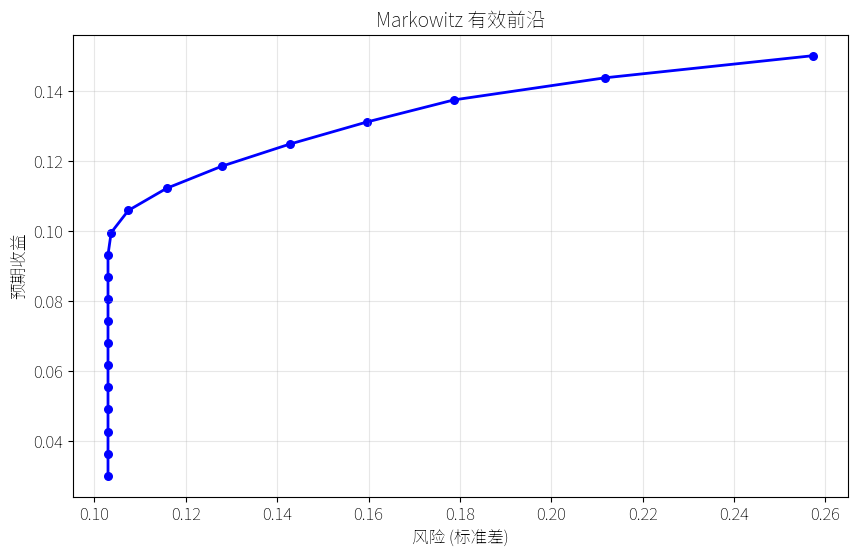

In [35]:
if HAS_CVXPY:
    # 有效前沿
    r_targets = np.linspace(0.03, 0.15, 20)
    risks = []
    returns = []

    for r_target in r_targets:
        x = cp.Variable(n_assets)
        objective = cp.Minimize(cp.quad_form(x, Sigma))
        constraints = [
            mu @ x >= r_target,
            cp.sum(x) == 1,
            x >= 0
        ]
        prob = cp.Problem(objective, constraints)
        try:
            prob.solve()
            if prob.status == 'optimal':
                risks.append(np.sqrt(prob.value))
                returns.append(r_target)
        except:
            pass

    plt.figure(figsize=(10, 6))
    plt.plot(risks, returns, 'b-', linewidth=2)
    plt.scatter(risks, returns, c='blue', s=30)
    plt.xlabel('风险 (标准差)', fontsize=12)
    plt.ylabel('预期收益', fontsize=12)
    plt.title('Markowitz 有效前沿', fontsize=14)
    plt.grid(True, alpha=0.3)
    plt.show()

---
## Part 10: Logistic回归的凸性

### 损失函数
$$L(w) = \sum_{i=1}^n \log(1 + e^{-y_i w^T x_i})$$

### 凸性证明
- 单项 $\ell(z) = \log(1 + e^{-z})$
- $\ell''(z) = \sigma(z)(1-\sigma(z)) \geq 0$ → $\ell$ 凸
- 复合仿射保持凸性 → $L(w)$ 凸
- 加 $L_2$ 正则化 → 强凸

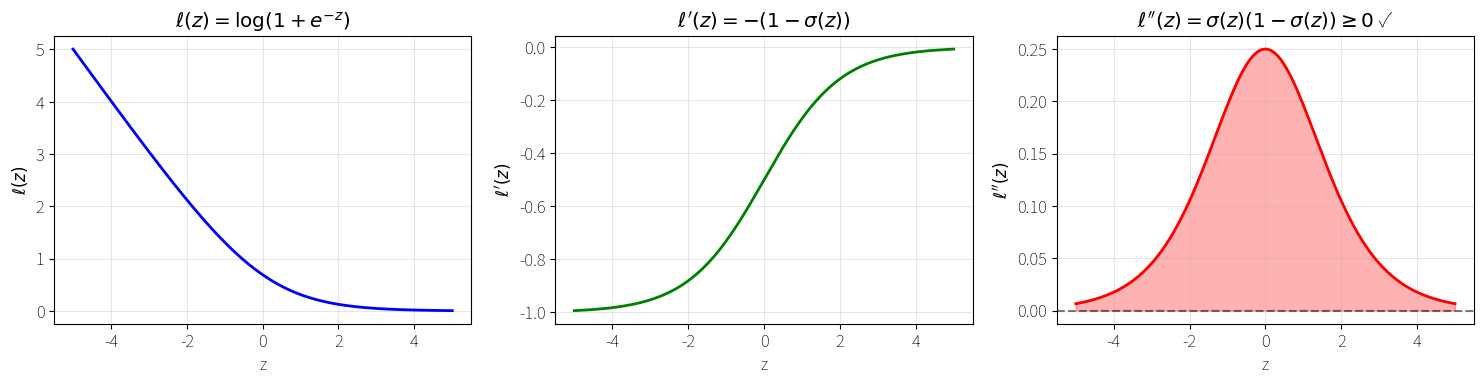

结论: ℓ''(z) >= 0 恒成立，所以 Logistic 损失函数是凸的


In [36]:
# Logistic损失函数的凸性
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

z = np.linspace(-5, 5, 200)

# ℓ(z) = log(1 + e^{-z})
ell = np.log(1 + np.exp(-z))

# ℓ'(z) = -σ(-z) = -(1 - σ(z))
ell_prime = -(1 - sigmoid(z))

# ℓ''(z) = σ(z)(1 - σ(z))
ell_double_prime = sigmoid(z) * (1 - sigmoid(z))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(z, ell, 'b-', linewidth=2)
axes[0].set_xlabel('z')
axes[0].set_ylabel('$\\ell(z)$')
axes[0].set_title('$\\ell(z) = \\log(1 + e^{-z})$')
axes[0].grid(True, alpha=0.3)

axes[1].plot(z, ell_prime, 'g-', linewidth=2)
axes[1].set_xlabel('z')
axes[1].set_ylabel("$\\ell'(z)$")
axes[1].set_title("$\\ell'(z) = -(1 - \\sigma(z))$")
axes[1].grid(True, alpha=0.3)

axes[2].plot(z, ell_double_prime, 'r-', linewidth=2)
axes[2].axhline(y=0, color='k', linestyle='--', alpha=0.5)
axes[2].fill_between(z, 0, ell_double_prime, alpha=0.3, color='red')
axes[2].set_xlabel('z')
axes[2].set_ylabel("$\\ell''(z)$")
axes[2].set_title("$\\ell''(z) = \\sigma(z)(1-\\sigma(z)) \\geq 0$ ✓")
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("结论: ℓ''(z) >= 0 恒成立，所以 Logistic 损失函数是凸的")

---
## 本周总结

### 数学定理
1. **凸性判定**：一阶条件（切线在下方）、二阶条件（Hessian半正定）
2. **对偶理论**：弱对偶（总成立）、强对偶（Slater条件）
3. **KKT条件**：原始可行、对偶可行、互补松弛、稳定性

### 现代视角
1. **规模决定方法**：小规模用内点法，大规模用一阶方法+GPU
2. **批量并行**：GPU批量优化，1000个问题 ≈ 1个问题的时间
3. **对偶的价值**：下界、影子价格、核技巧

### 核心直觉
- 互补松弛 = 稀缺资源才有价格
- 支持向量 = 对偶变量非零的点
- 凸 = 局部即全局

---
## 练习

1. 证明：如果 $f$ 和 $g$ 都是凸函数，则 $\max\{f(x), g(x)\}$ 也是凸函数。

2. 为什么凸优化的等式约束只能是仿射的？

3. 考虑问题 $\min x^2$ s.t. $x \geq 2$：
   - 写出KKT条件
   - 求解最优解和Lagrange乘子
   - 验证互补松弛条件

4. 在SVM中，如果所有训练样本都正确分类且远离边界，会发生什么？

5. 对不同规模的QP问题 ($n = 1000, 5000, 10000$)，比较CVXPY内点法和GPU梯度下降的求解时间。